In [1]:
from ray import tune
import pandas as pd

In [2]:
from ray.tune import ExperimentAnalysis

analysis = ExperimentAnalysis("/home/jgerrits/portfolio-S3/logs/ray_flowers/train_2026-03-14_14-38-19")

df_it2 = analysis.dataframe()
print(df_it2.head())

   train_loss  train_accuracy  val_loss  val_accuracy  epoch   timestamp  \
0    1.753173        0.578431  2.574618      0.359804     10  1773501513   
1    2.681519        0.390196  2.937347      0.314706     10  1773497388   
2    2.213907        0.392157  4.417329      0.193137     10  1773503789   
3    2.272784        0.408824  3.009180      0.256863     10  1773499308   
4    0.875365        0.791176  2.810693      0.341176     10  1773506727   

  checkpoint_dir_name   done  training_iteration     trial_id  ...  \
0                None  False                  10  0ffef_00004  ...   
1                None  False                  10  0ffef_00001  ...   
2                None  False                  10  0ffef_00006  ...   
3                None  False                  10  0ffef_00002  ...   
4                None  False                  10  0ffef_00008  ...   

                                    hostname       node_ip  \
0  uos3jgerrits7.uos3-han.src.surf-hosted.nl  192.168.1.37  

In [3]:
print(
    df_it2[
        [
            "config/lr",
            "config/num_layers",
            "config/dropout",
            "train_accuracy",
            "val_accuracy",
        ]
    ].sort_values("val_accuracy", ascending=False)
)

    config/lr  config/num_layers  config/dropout  train_accuracy  val_accuracy
6      0.0003                  6             0.3        0.683333      0.373529
0      0.0003                  5             0.1        0.578431      0.359804
4      0.0003                  6             0.1        0.791176      0.341176
7      0.0003                  4             0.1        0.433333      0.327451
8      0.0003                  5             0.3        0.513725      0.324510
1      0.0003                  4             0.3        0.390196      0.314706
5      0.0010                  4             0.3        0.363725      0.286275
3      0.0010                  4             0.1        0.408824      0.256863
10     0.0010                  6             0.3        0.326471      0.235294
11     0.0010                  6             0.1        0.275490      0.200980
2      0.0010                  5             0.1        0.392157      0.193137
9      0.0010                  5             0.3    

# Heatmap

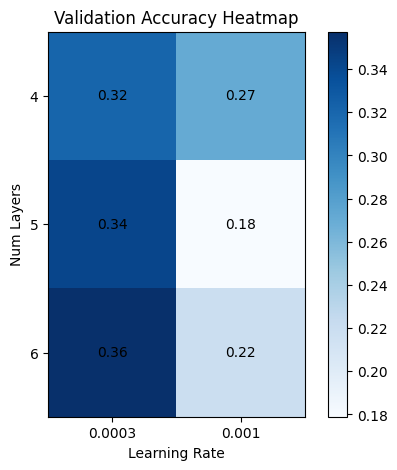

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_it2.pivot_table(
    values="val_accuracy",
    index="config/num_layers",
    columns="config/lr"
)

plt.figure(figsize=(6,5))
plt.imshow(pivot, cmap="Blues")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center",
                 va="center",
                 color="black")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Learning Rate")
plt.ylabel("Num Layers")

plt.title("Validation Accuracy Heatmap")

plt.colorbar()

plt.show()

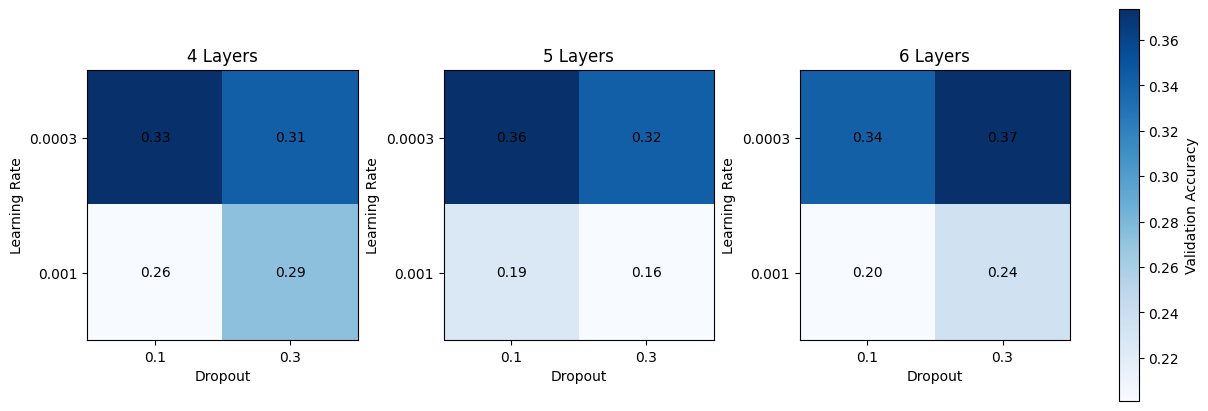

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

layer_values = [4, 5, 6]

for ax, layer in zip(axes, layer_values):
    subset = df_it2[df_it2["config/num_layers"] == layer]

    pivot = subset.pivot_table(
        values="val_accuracy",
        index="config/lr",
        columns="config/dropout"
    )

    im = ax.imshow(pivot, cmap="Blues")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(
                j,
                i,
                f"{pivot.iloc[i, j]:.2f}",
                ha="center",
                va="center"
            )

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Dropout")
    ax.set_ylabel("Learning Rate")
    ax.set_title(f"{layer} Layers")


fig.colorbar(im, ax=axes, label="Validation Accuracy")

plt.show()

# Output appendix files

In [10]:
def create_appendix_df(
    df,
    columns,
    round_cols=None,
    decimals=2,
    sort_col=None,
    ascending=True
):
    """
    Create a cleaned dataframe for appendix tables.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe (e.g. Ray Tune results).
    columns : list
        Columns to include in the appendix table.
    round_cols : list, optional
        Columns that should be rounded.
    decimals : int
        Number of decimals for rounding.
    sort_col : str, optional
        Column used for sorting.
    ascending : bool
        Sort order.

    Returns
    -------
    pandas.DataFrame
    """

    appendix_df = df[columns].copy()

    if round_cols:
        appendix_df[round_cols] = appendix_df[round_cols].round(decimals)

    if sort_col:
        appendix_df = appendix_df.sort_values(sort_col, ascending=ascending)

    return appendix_df

In [11]:
appendix_df_it2 = create_appendix_df(
    df_it2,
    columns=[
        "trial_id",
        "config/lr",
        "config/base_channels",
        "config/num_layers",
        "config/dropout",
        "train_accuracy",
        "val_accuracy",
        "val_loss",
    ],
    round_cols=["train_accuracy", "val_accuracy", "val_loss"],
    decimals=2,
    sort_col="trial_id",
)

appendix_df_it2

,trial_id,config/lr,config/base_channels,config/num_layers,config/dropout,train_accuracy,val_accuracy,val_loss
7,0ffef_00000,0.0003,64,4,0.1,0.43,0.33,2.86
1,0ffef_00001,0.0003,64,4,0.3,0.39,0.31,2.94
3,0ffef_00002,0.0010,64,4,0.1,0.41,0.26,3.01
5,0ffef_00003,0.0010,64,4,0.3,0.36,0.29,2.96
0,0ffef_00004,0.0003,64,5,0.1,0.58,0.36,2.57
8,0ffef_00005,0.0003,64,5,0.3,0.51,0.32,2.71
2,0ffef_00006,0.0010,64,5,0.1,0.39,0.19,4.42
9,0ffef_00007,0.0010,64,5,0.3,0.36,0.16,4.09
4,0ffef_00008,0.0003,64,6,0.1,0.79,0.34,2.81
6,0ffef_00009,0.0003,64,6,0.3,0.68,0.37,2.48
